In [6]:
#IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [7]:
#Load Dataset

df = pd.read_excel(r"C:\Users\bhamr\Downloads\archive (1)\online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:

#Data Cleaning
df = df.dropna(subset=['Customer ID'])
df['Description'] = df['Description'].fillna('Unknown')

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [9]:
#Feature Engineering
df['TotalPrice'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)

In [10]:
#RFM Analysis
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

rfm.head()

,Recency,Frequency,Monetary,Churn
Customer ID,,,,
12346,164,11,372.86,1
12347,2,2,1323.32,0
12348,73,1,222.16,0
12349,42,3,2671.14,0
12351,10,1,300.93,0


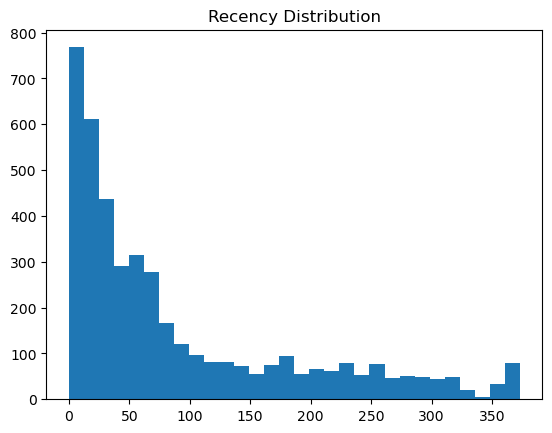

In [14]:
#Exploratory Data Analysis
#Recency Distribution
plt.hist(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.show()


In [ ]:
#Insight: Most customers are recently active.

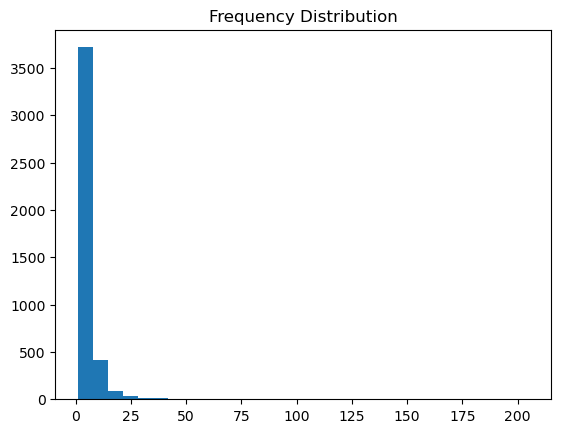

In [15]:
#Frequency Distribution
plt.hist(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.show()

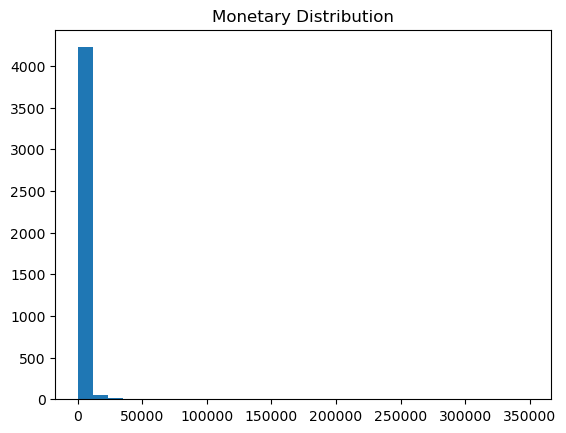

In [17]:
#Monetary Distribution
plt.hist(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")
plt.show()

In [ ]:

#Insight: Revenue is highly skewed (few big spenders).

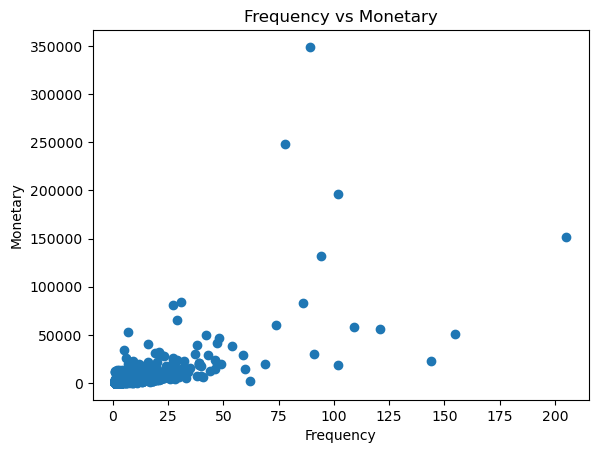

In [18]:
#Frequency vs Monetary
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Monetary")
plt.show()

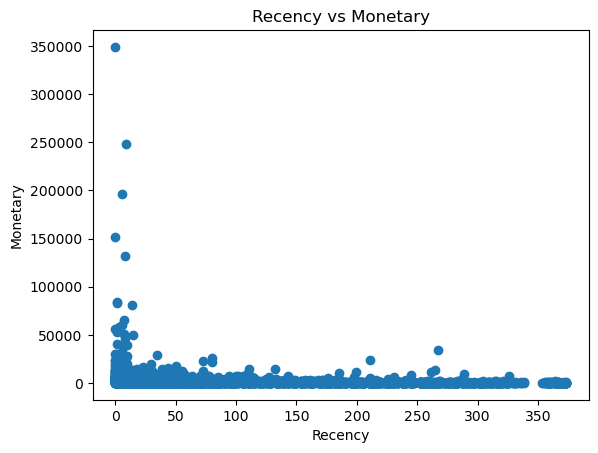

In [19]:
#Recency vs Monetary
plt.scatter(rfm['Recency'], rfm['Monetary'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Recency vs Monetary")
plt.show()

In [20]:
#Logistic Regression Model
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       573
           1       1.00      1.00      1.00       290

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



In [21]:
#Random Forest Model

X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_val)

print(classification_report(y_val, pred))


              precision    recall  f1-score   support

           0       0.73      0.77      0.75       573
           1       0.49      0.44      0.46       290

    accuracy                           0.66       863
   macro avg       0.61      0.60      0.61       863
weighted avg       0.65      0.66      0.65       863



In [22]:
#Feature Importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_imp

,Feature,Importance
1,Monetary,0.889091
0,Frequency,0.110909
